In [2]:
# === TASK 1 – REGRESJON (task1_data.csv) ===
# 5000 observasjoner, 6 numeriske prediktorer (x1–x6), kontinuerlig respons y.
# Ingen kategoriske variabler → ingen dummies nødvendig.
# Standardiser X for Ridge, LASSO og MLP (ikke for OLS, tree, RF, boost).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
import sklearn.linear_model as skm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

df = pd.read_csv('task1_data.csv')
print(df.shape)   # (5000, 7)
df.head()

# Forklaringsvariabler og responsvariabel
predictors = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
X = df[predictors]   # design-matrise: 5000 × 6, alle numeriske
y = df['y']          # kontinuerlig respons

# Forelesers 50/50-split
np.random.seed(123)
n      = len(df)
ntrain = n // 2
ind    = np.random.choice(np.arange(n), size=ntrain, replace=False)
mask   = np.ones(n, dtype=bool)
mask[ind] = False

X_train, X_test = X.iloc[ind], X.iloc[mask]
y_train, y_test = y.iloc[ind], y.iloc[mask]

# Standardisert versjon – bruk for Ridge, LASSO, MLP
scaler    = StandardScaler(with_mean=True, with_std=True)
X_train_s = scaler.fit_transform(X_train)  # fit KUN på treningsdata
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'y: mean={y_train.mean():.2f}, std={y_train.std():.2f}')

(5000, 7)
Train: (2500, 6), Test: (2500, 6)
y: mean=3.49, std=3.42


In [ ]:
# === OLS – ORDINÆR LINEÆR REGRESJON ===
# Modell: y = b0 + b1*x1 + ... + bp*xp + e,  der e ~ N(0, sigma²).
# OLS minimerer RSS = sum((y_i - yhat_i)²) og gir analytisk løsning: b = (X'X)⁻¹ X'y.
# Koeffisienter tolkes som: en enhets økning i xj endrer forventet y med bj,
#   gitt at alle andre prediktorer holdes konstant (ceteris paribus).
# P-verdi for bj: sannsynligheten for å observere denne t-verdien hvis bj=0 i populasjonen.
#   Lav p-verdi (< 0.05) = prediktor er signifikant assosiert med y gitt modellen.
# R²: andel av variansen i y som forklares av modellen. Øker alltid med flere variabler.
# OLS antar: linearitet, uavhengige residualer, konstant varians (homoskedastisitet).
# sm.add_constant legger til kolonne av 1-ere slik at modellen får et intercept.
X_train_c = sm.add_constant(X_train)
ols = sm.OLS(y_train, X_train_c).fit()
print(ols.summary())  # koeffisienter, t-test, p-verdier, R², F-test

X_test_c = sm.add_constant(X_test)
pred_ols = ols.predict(X_test_c)
mse_ols  = np.mean((y_test - pred_ols)**2)
print(f'Test MSE (OLS): {mse_ols:.4f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     638.7
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        01:34:54   Log-Likelihood:                -5454.2
No. Observations:                2500   AIC:                         1.092e+04
Df Residuals:                    2493   BIC:                         1.096e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4378      0.043     79.985      0.0

Tree MSE: 3.8146


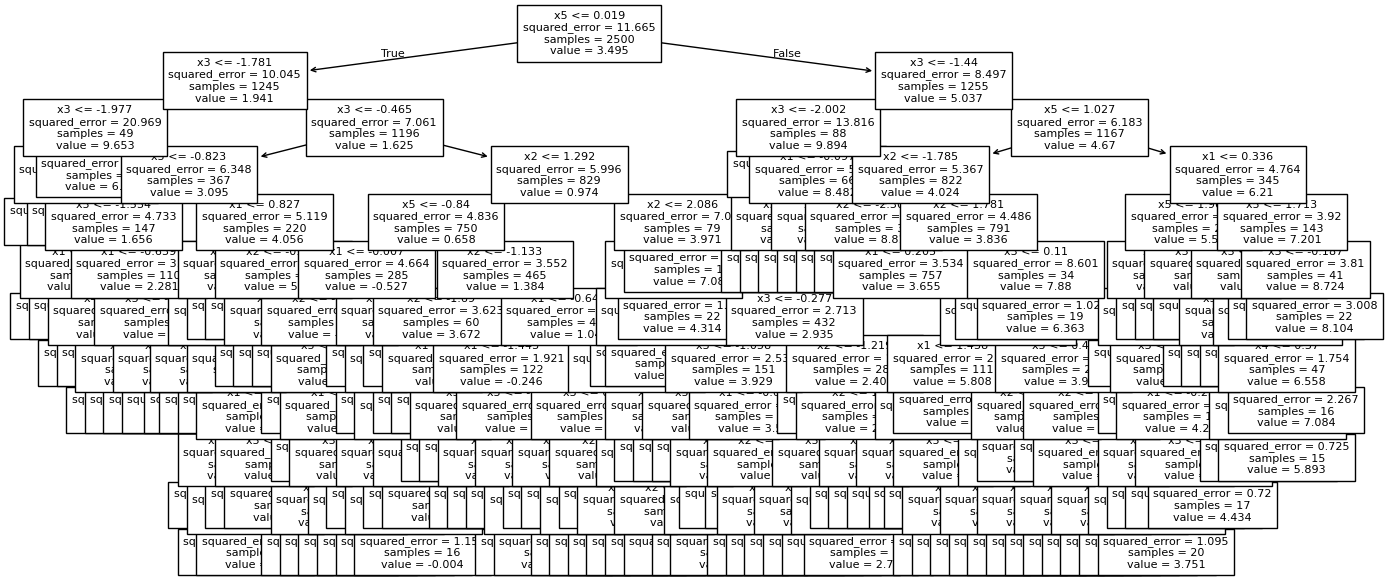

In [14]:
# === REGRESJONSTRE ===
# Algoritme: rekursiv binær splitting (CART) av prediktorrommet.
# I hvert steg velges prediktoren xj og splittverdien s som minimerer
#   RSS = sum_{R1}(yi - yhat_R1)² + sum_{R2}(yi - yhat_R2)².
# Bladprediksjon = gjennomsnitt av y for observasjonene i bladet.
# Fordel: lett å tolke, håndterer ikke-linearitet og interaksjoner automatisk.
# Ulempe: høy varians – liten endring i data kan gi helt annet tre (se bagging/RF).
# Overfitting begrenses med max_depth (maks dybde) eller min_samples_leaf
#   (minimum observasjoner per blad). Alternativt: pruning med ccp_alpha (se 'prune').
tree = DecisionTreeRegressor(min_samples_leaf=15, max_depth=11, random_state=0)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
mse_tree  = np.mean((y_test - pred_tree)**2)
print(f'Tree MSE: {mse_tree:.4f}')

plt.figure(figsize=(14, 6))
plot_tree(tree, feature_names=X_train.columns, filled=False, fontsize=8)
plt.tight_layout(); plt.show()

RF MSE: 2.4743


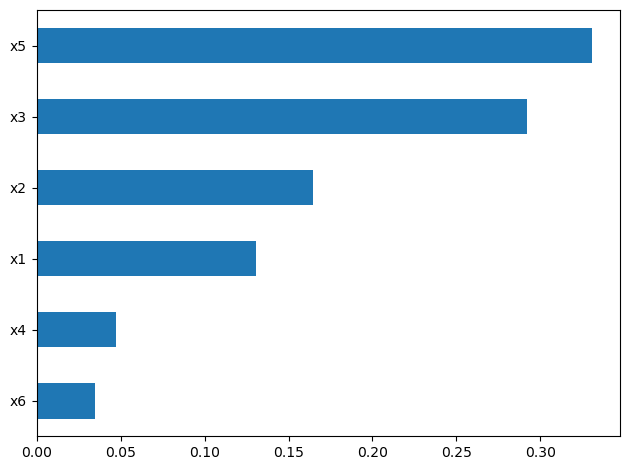

In [7]:
# === RANDOM FOREST – REGRESJON ===
# Bagging + ekstra dekorrelering: ved hvert split velges KUN m < p prediktorer tilfeldig.
# Dette forhindrer at ett sterkt dominerende prediktor alltid splitter øverst,
#   noe som gjør bagging-trærne korrelerte og reduserer variansgevinsten.
# Tommelfingerregel: m = sqrt(p) for klassifikasjon, m = p/3 for regresjon.
# Mer trær (n_estimators) = bedre, men avtar marginalt – 500 er praktisk standard.
# feature_importances_: gjennomsnittlig reduksjon i RSS per variabel over alle B trær.
#   Tolkes som prediktiv betydning, IKKE kausal effekt.
# RF gir ikke tolkbare koeffisienter, men gir god prediksjon og feature importance.
rf = RandomForestRegressor(n_estimators=500,
                           max_features=int(np.sqrt(X_train.shape[1])),  # m = sqrt(p)
                           random_state=123)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mse_rf  = np.mean((y_test - pred_rf)**2)
print(f'RF MSE: {mse_rf:.4f}')

# Feature importance: prediktiv viktighet – ikke kausal effekt
pd.Series(rf.feature_importances_, index=X_train.columns).sort_values().plot.barh()
plt.tight_layout(); plt.show()

In [ ]:
# === TREE PRUNING – COST-COMPLEXITY ===
# Overfittet tre beskjæres ved å minimere: RSS + alpha * |T|,
#   der |T| = antall blader og alpha er kompleksitetsstraffen.
# Alpha=0 → fullt tre. Høy alpha → ett blad (bare intercepten).
# cost_complexity_pruning_path() finner alle kritiske alpha-verdier der
#   ett bladpar kollapseres – dette er 'weakest link pruning'.
# Optimal alpha velges via kryssvalidering på treningsdata.
# Prosessen: (1) voks fullt tre, (2) finn kandidat-alphaer, (3) CV for beste alpha,
#   (4) refit med beste alpha på all treningsdata.
big_tree = DecisionTreeRegressor(min_samples_leaf=2, random_state=0)  # overfittet utgangspunkt
big_tree.fit(X_train, y_train)
path = big_tree.cost_complexity_pruning_path(X_train, y_train)  # alle kritiske alphaer

kfold = KFold(5, shuffle=True, random_state=10)
grid  = GridSearchCV(DecisionTreeRegressor(random_state=0),
                     {'ccp_alpha': path.ccp_alphas},
                     refit=True, cv=kfold,
                     scoring='neg_mean_squared_error')  # lavest CV-MSE = beste alpha
grid.fit(X_train, y_train)

pruned    = grid.best_estimator_   # optimalt tre, refittet på all treningsdata
pred_prun = pruned.predict(X_test)
mse_prun  = np.mean((y_test - pred_prun)**2)
print(f'Pruned tree MSE: {mse_prun:.4f}, alpha: {grid.best_params_["ccp_alpha"]:.4f}')

Pruned tree MSE: 3.3464, alpha: 0.0043


In [16]:
# === GRADIENT BOOSTING – REGRESJON ===
# Additivt ensemble: F(x) = sum_{b=1}^{B} learning_rate * h_b(x),
#   der hvert tre h_b fitter de NEGATIVE GRADIENTENE (residualene) fra forrige modell.
# Sekvensielt: hvert nytt tre korrigerer feilene til summen av alle tidligere trær.
# learning_rate (shrinkage): skaler ned bidraget fra hvert tre – hindrer overfitting.
#   Lav learning_rate + høy n_estimators = bedre generalisering, men tregere.
# max_depth=2 (decision stumps) er standard – boosting kombinerer mange SVAKE lærere.
# Bias-variance: boosting reduserer BIAS iterativt (vs. bagging som reduserer varians).
# Overfitter ved for høy n_estimators eller learning_rate – bruk CV for å tune.
# Forelesers standard: 1000 trær, learning_rate=0.01, max_depth=2.
boost = GradientBoostingRegressor(n_estimators=1000,
                                  learning_rate=0.01,  # krymper bidraget per tre
                                  max_depth=2,         # grunne trær – svake lærere
                                  random_state=123)
boost.fit(X_train, y_train)
pred_boost = boost.predict(X_test)
mse_boost  = np.mean((y_test - pred_boost)**2)
print(f'Boost MSE: {mse_boost:.4f}')

Boost MSE: 2.0769


In [17]:
# ============================================================
# INTERPRETATION AND JUSTIFICATION GUIDE – BAN404
# ============================================================
#
# ============================================================
# COMPARING MODELS (which is best?)
# ============================================================
#
# Regression: compare Test MSE. Lower = better.
# Classification: compare error rate AND row proportions (sensitivity/specificity).
#   Accuracy alone is misleading with imbalanced classes.
#
# RF MSE << OLS MSE
#   → Non-linear structure or interactions in the data.
#   → OLS has high bias (wrong functional form).
#   → Solution: use RF, Boost, or GAM.
#
# Ridge/LASSO MSE ≈ OLS MSE
#   → Regularisation does not help → the problem is not overfitting (high variance).
#   → The problem is bias (wrong model form) → try RF/Boost.
#
# Ridge/LASSO MSE << OLS MSE
#   → OLS was overfitting → regularisation helped reduce variance.
#   → Many correlated predictors or too little data relative to p.
#
# Train MSE << Test MSE (large gap)
#   → Overfitting: model memorises training data, does not generalise.
#   → Fix: regularise (Ridge/LASSO), prune tree, reduce max_depth, use RF/Boost.
#
# Train MSE ≈ Test MSE (both high)
#   → Underfitting: model is too simple.
#   → Fix: more flexible model, add features, higher polynomial degree.
#
# ============================================================
# INTERPRETING OLS OUTPUT
# ============================================================
#
# Coefficient bj:
#   A one-unit increase in xj changes expected y by bj,
#   holding all other predictors constant (ceteris paribus).
#   Sign: positive = xj increases y. Negative = xj decreases y.
#
# p-value for bj (t-test):
#   P(observing this t-value | bj = 0 in the population).
#   p < 0.05 → statistically significant at the 5% level.
#   p > 0.05 → no evidence that bj ≠ 0 given the other predictors in the model.
#   Important: insignificant ≠ irrelevant. May be correlated with other predictors.
#
# R²:
#   Proportion of total variance in y explained by the model.
#   R² = 0.60 → the model explains 60% of the variation in y.
#   Always increases with more predictors – use Adjusted R² to compare models.
#
# F-test (bottom of summary):
#   Tests whether ALL coefficients are jointly zero.
#   Low p-value → at least one predictor has a real association with y.
#
# ============================================================
# INTERPRETING LOGISTIC REGRESSION OUTPUT
# ============================================================
#
# Coefficient bj (log-odds):
#   A one-unit increase in xj changes the LOG-ODDS of Y=1 by bj.
#   exp(bj) = odds ratio: multiplicative effect on odds per unit increase in xj.
#   bj > 0 → higher xj increases P(Y=1). bj < 0 → decreases P(Y=1).
#
# p-value: z-test (not t-test). Same interpretation as OLS.
#
# predict() returns P(Y=1|X) – probabilities, not classes.
#   Default threshold 0.5 is often too high for imbalanced classes.
#   Lower threshold → higher sensitivity (catch more positives), lower specificity.
#
# ============================================================
# INTERPRETING CONFUSION TABLE / ROW PROPORTIONS
# ============================================================
#
# Row 0: [specificity, 1-specificity]  → how well does the model classify negatives?
# Row 1: [1-sensitivity, sensitivity]  → how well does the model classify positives?
#
# High accuracy but low sensitivity (row 1):
#   → Model is biased toward the majority class.
#   → Fix: lower the threshold (see 'terskel').
#
# Choosing threshold:
#   Depends on the cost of FP vs FN.
#   Churn: missing a churner (FN) is more costly than a false alarm (FP).
#   → Prefer higher sensitivity, accept lower specificity.
#
# ============================================================
# INTERPRETING RANDOM FOREST / BOOSTING
# ============================================================
#
# feature_importances_:
#   Average reduction in RSS (or Gini) per variable across all trees.
#   Higher = more predictive. NOT a causal effect.
#   Important: a variable can have high importance even without a linear relationship.
#
# RF does not give p-values or coefficients.
#   If interpretation of individual effects is required → use OLS or logistic reg.
#
# ============================================================
# INTERPRETING PCA
# ============================================================
#
# PropVar / CumProp:
#   PC1 explains X% of total variance. Choose K PCs where CumProp > 80-90%.
#   Scree plot: look for an 'elbow' – the point where adding more PCs gives little gain.
#
# Loadings:
#   Large absolute loading → that variable contributes strongly to the PC.
#   PC1 with high loadings on x1 and x3 → PC1 captures the x1/x3 dimension.
#   Opposite signs in loadings → contrast between those variables.
#
# ============================================================
# STANDARD EXAM JUSTIFICATION PHRASES
# ============================================================
#
# 'I choose RF because test MSE is lower than OLS (X vs Y).'
# 'The gap between OLS and RF indicates non-linear structure in the data.'
# 'Ridge and LASSO do not improve over OLS, so the issue is model form, not variance.'
# 'I lower the threshold because the positive class is rare (~15%) and'
#   'missing a positive (FN) is more costly than a false alarm (FP).'
# 'x1 is statistically significant (p < 0.05): a one-unit increase in x1'
#   'is associated with a Y-unit increase in y, holding all else constant.'
# 'The model explains R²% of the variation in y on training data.'
# 'Test MSE is used for model comparison – it measures performance on unseen data.'

In [19]:
# === CUSTOMER DATA – CLASSIFICATION (customer_data.csv) ===
# 2666 observations, 20 columns, response: Churn (bool → int 0/1).
# Class balance: ~85.5 % False (0), ~14.5 % True (1) – IMBALANCED.
# Leakage variables removed: charge columns are perfectly correlated with minutes.
# Categorical: International plan, Voice mail plan, Area code → dummies.
# State has 50 levels – too many for dummies, drop it.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, KFold

df = pd.read_csv('customer_data.csv')
print(df.shape)   # (2666, 20)
print(df['Churn'].value_counts())  # False: 2278, True: 388

# Drop leakage variables (charge = minutes * rate, perfectly correlated)
# and State (50 categories, too high cardinality)
df_model = df.drop(columns=[
    'State',
    'Total day charge',    # = Total day minutes * 0.17
    'Total eve charge',    # = Total eve minutes * 0.085
    'Total night charge',  # = Total night minutes * 0.045
    'Total intl charge'    # = Total intl minutes * 0.27
])

# Convert Churn bool → int (required by statsmodels and sklearn)
df_model['Churn'] = df_model['Churn'].astype(int)

# Create dummies for categorical variables (drop_first avoids the dummy trap)
# dtype=int gives 0/1 columns (not bool) – required by statsmodels
df_model = pd.get_dummies(
    df_model,
    columns=['Area code', 'International plan', 'Voice mail plan'],
    drop_first=True,
    dtype=int
)
print(df_model.shape)  # (2666, 16)

# Lecturer's 50/50 split
np.random.seed(123)
n      = len(df_model)
ntrain = n // 2
ind    = np.random.choice(np.arange(n), size=ntrain, replace=False)
mask   = np.ones(n, dtype=bool)
mask[ind] = False

train = df_model.iloc[ind]
test  = df_model.iloc[mask]

X_train = train.drop(columns='Churn')
y_train = train['Churn']
X_test  = test.drop(columns='Churn')
y_test  = test['Churn']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.4f}, test: {y_test.mean():.4f}')


(2666, 20)
Churn
False    2278
True      388
Name: count, dtype: int64
(2666, 16)
Train: (1333, 15), Test: (1333, 15)
Churn rate train: 0.1508, test: 0.1403


In [20]:
# === LOGISTIC REGRESSION ===
# Model: P(Y=1|X) = sigmoid(b0 + b1*x1 + ...) = 1 / (1 + exp(-Xb)).
# Estimated with maximum likelihood (MLE), not OLS – no closed form.
# Coefficients are linear in LOG-ODDS: log(P/(1-P)) = b0 + b1*x1 + ...
#   bj > 0: higher xj increases P(Y=1). bj < 0: higher xj decreases P(Y=1).
#   exp(bj) = odds ratio: multiplicative effect on odds per one-unit increase in xj.
# p-values: z-test (not t-test as in OLS) – interpreted the same way.
# predict() returns probabilities P(Y=1|X), not classes – see 'terskel' for classification.
# Default threshold 0.5 is often too high with imbalanced classes.
X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

logreg = sm.GLM(y_train, X_train_c, family=sm.families.Binomial()).fit()
print(logreg.summary())  # coefficients, z-test, p-values, deviance

prob  = logreg.predict(X_test_c)         # P(Y=1|X) – probabilities
pred  = (prob > 0.5).astype(int)          # classify: adjust threshold for imbalance
cm    = pd.crosstab(y_test, pred, rownames=['Actual'], colnames=['Predicted'])
props = pd.crosstab(y_test, pred, normalize='index').round(3)
print(cm)
print(props)
print(f'Accuracy: {np.mean(pred == y_test):.4f}')

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 1333
Model:                            GLM   Df Residuals:                     1317
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -442.88
Date:                Tue, 19 May 2026   Deviance:                       885.76
Time:                        02:12:23   Pearson chi2:                 1.26e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1678
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -7